# 01 — UCI Heart Disease: Initial Data Analysis

**Industry context.** Clinical triage / cardiovascular risk decision support. We use the public UCI Heart Disease dataset (no PHI) to prototype a risk-stratification pipeline.

**Lineage.** The Initial Data Analysis (IDA) discipline followed here — distribution shape, missing/sentinel scan, group-level rates, chi-square + Cramer's V, explicit limitations — is adapted from Project 2 (Data & Statistical Reasoning, UCI Bank Marketing) and is the foundation for reproducible analytic work (Lusa et al., 2024).

**Educational artifact only. Not for clinical use.**

In [1]:
# Notebook bootstrap: make the project root importable so we can call src.data_loader
# from a notebook started in the notebooks/ subdirectory, then seed RNGs.

import sys, os
from pathlib import Path
# Make the project root importable when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.data_loader import (
    load_heart_disease,
    FEATURE_DICTIONARY,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    TARGET_COL,
)

pd.set_option('display.max_columns', 50)
np.random.seed(42)

## 1. Load and inspect

In [ ]:
# Load the cached UCI Heart Disease dataset (downloaded on first call,
# then served from data/raw/heart_disease.csv). df.head() previews the first rows.

df = load_heart_disease() # calls src.data_loader.load_heart_disease()
print('Shape:', df.shape)
df.head()

Shape: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0


In [3]:
# Print the project-level data dictionary so anyone reading the notebook
# knows what each column represents before we start interpreting plots.

# Feature dictionary
for k, v in FEATURE_DICTIONARY.items():
    print(f'{k:10s}  {v}')

age         Age in years.
sex         Sex (1 = male, 0 = female).
cp          Chest pain type (1 typical angina, 2 atypical, 3 non-anginal, 4 asymptomatic).
trestbps    Resting blood pressure on admission (mm Hg).
chol        Serum cholesterol (mg/dl).
fbs         Fasting blood sugar > 120 mg/dl (1 = true, 0 = false).
restecg     Resting electrocardiographic results (0 normal, 1 ST-T abnormality, 2 LV hypertrophy).
thalach     Maximum heart rate achieved during exercise.
exang       Exercise-induced angina (1 = yes, 0 = no).
oldpeak     ST depression induced by exercise relative to rest.
slope       Slope of the peak exercise ST segment (1 up, 2 flat, 3 down).
ca          Number of major vessels (0-3) colored by fluoroscopy.
thal        Thalassemia (3 normal, 6 fixed defect, 7 reversible defect).
num         Original severity target (0-4); 0 = no disease, >0 = disease present.
target      Binary outcome derived from `num` (1 = disease present).


In [8]:
# Quick descriptive summary (count/mean/std/min/quartiles/max) for every column.
# Useful sanity check for sentinel values and extreme outliers.

df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Missing / sentinel scan
Lineage: P2 — categorical sentinels (e.g. `unknown` in Bank Marketing) and NaNs were enumerated before any inference.

In [9]:
# Missing-value scan. UCI Heart Disease uses NaN for the rare missing entries
# in ca/thal; we surface counts here before any imputation.

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing if len(missing) else '(none)')

Columns with missing values:
ca      4
thal    2
dtype: int64


## 3. Target balance

In [10]:
# Target class balance: count and percentage for label 0 (no disease) and 1 (disease).
# This justifies the choice of ROC-AUC over plain accuracy as headline metric.

counts = df[TARGET_COL].value_counts().sort_index()
rates = (counts / counts.sum() * 100).round(2)
summary = pd.DataFrame({'count': counts, 'percent': rates})
summary.index = ['no disease (0)', 'disease (1)']
summary

,count,percent
no disease (0),164,54.13
disease (1),139,45.87


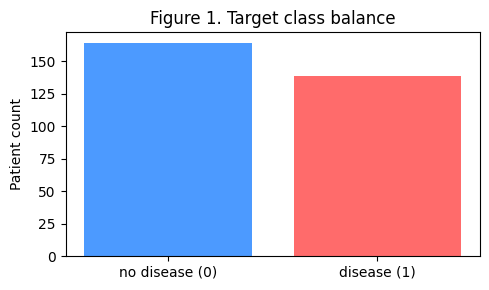

In [11]:
# Figure 1: simple bar chart of target class counts so the imbalance is visible at a glance.

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(summary.index, summary['count'], color=['#4C9AFF', '#FF6B6B'])
ax.set_title('Figure 1. Target class balance')
ax.set_ylabel('Patient count')
plt.tight_layout(); plt.show()

<!-- chart-narration -->
**Reading Figure 1.** Roughly 46% of patients in the cohort have heart disease (label 1) and 54% do not (label 0). The split is close enough to balanced that we can use ROC-AUC as the headline metric without resampling, but we still report per-class precision/recall to catch any class-specific failure mode.

## 4. Numeric features — distributions and skew
Lineage: P2 reported skew for the variables most relevant to client-level inference; we do the same here for clinical variables.

In [12]:
# Compute Fisher-Pearson skewness for each numeric feature.
# |skew| > 1 indicates substantial asymmetry; here oldpeak is the only highly skewed one.

skew_table = df[NUMERIC_FEATURES].skew().round(3).rename('skew').to_frame()
skew_table

,skew
age,-0.209
trestbps,0.706
chol,1.136
thalach,-0.537
oldpeak,1.270


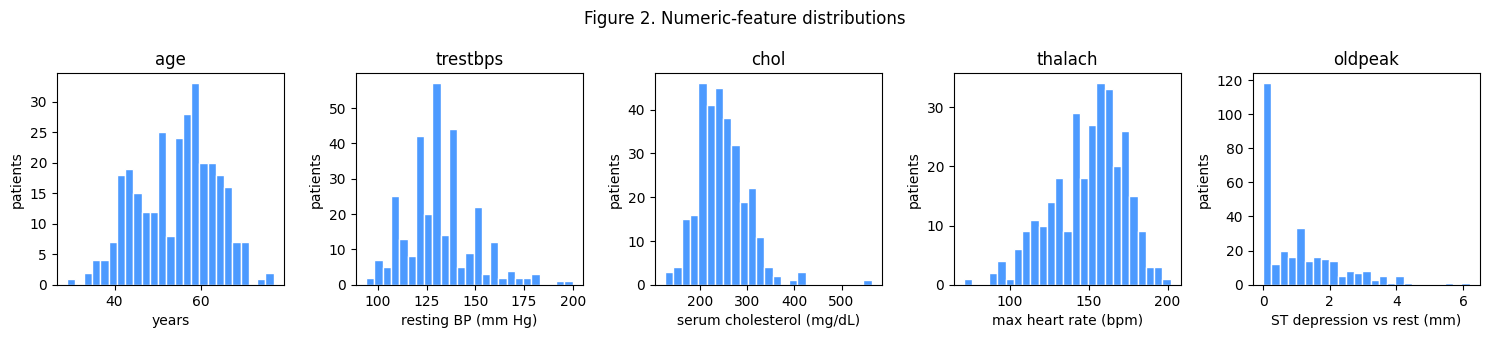

In [13]:
# Figure 2: histogram per numeric feature with clinical units on the x-axis
# and patient count on the y-axis, so the distribution shape is interpretable
# without needing the data dictionary open.

NUMERIC_UNITS = {
    "age":      "years",
    "trestbps": "resting BP (mm Hg)",
    "chol":     "serum cholesterol (mg/dL)",
    "thalach":  "max heart rate (bpm)",
    "oldpeak":  "ST depression vs rest (mm)",
}

fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(3 * len(NUMERIC_FEATURES), 3.4))
for ax, col in zip(axes, NUMERIC_FEATURES):
    ax.hist(df[col].dropna(), bins=25, color='#4C9AFF', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(NUMERIC_UNITS.get(col, col))
    ax.set_ylabel('patients')
fig.suptitle('Figure 2. Numeric-feature distributions')
plt.tight_layout(); plt.show()

<!-- chart-narration -->
**Reading Figure 2.** Per-feature shape and red flags:
- `age` (years): roughly bell-shaped, range 29-77, centered ~55. No outliers.
- `trestbps` (resting blood pressure, mm Hg): centered ~130, mild right tail. A few patients exceed 180 mm Hg (hypertensive crisis range) - kept as legitimate values.
- `chol` (serum cholesterol, mg/dL): centered ~245, long upper tail. One value >550 looks like a possible outlier but is kept (gradient-boosting handles it).
- `thalach` (max heart rate, bpm): centered ~150, bell-shaped. Lower values are risk-relevant (poor exercise capacity).
- `oldpeak` (ST depression, mm): heavily right-skewed with a large spike at 0. Most patients showed no exercise-induced ischemia; the right tail is the high-risk subset.

Skew alone is not a problem here - tree models are scale- and skew-invariant, and the DL pipeline uses `StandardScaler`.

## 5. Disease rate by categorical feature
Lineage: P2 plotted subscription rate by job with the overall rate as a reference line. We apply the same idea per clinical category.

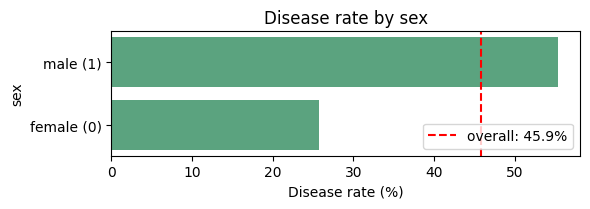

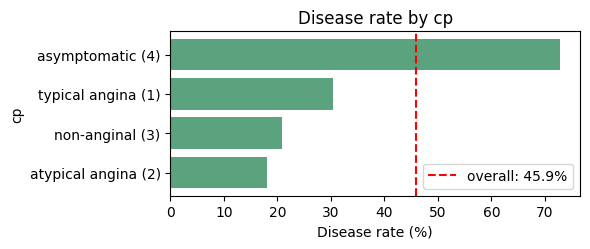

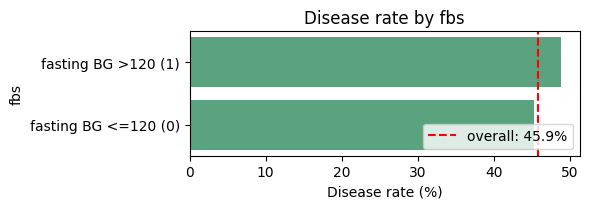

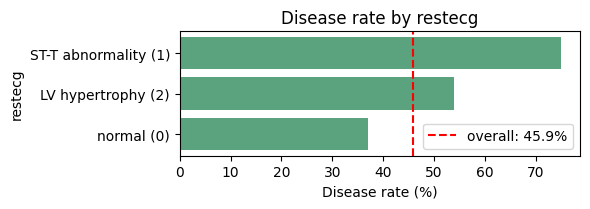

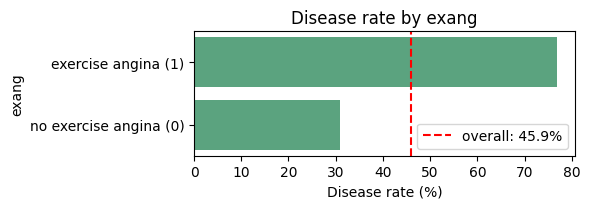

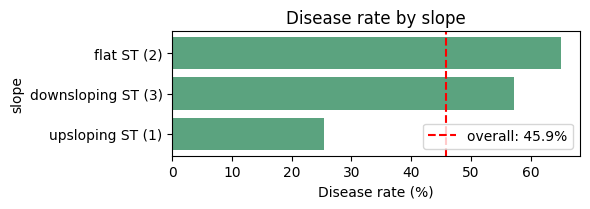

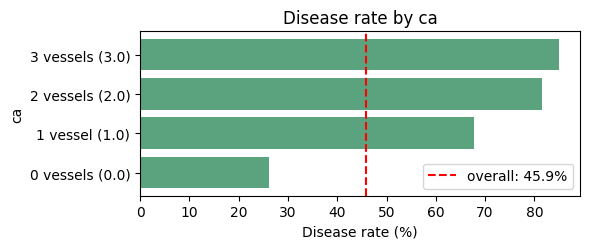

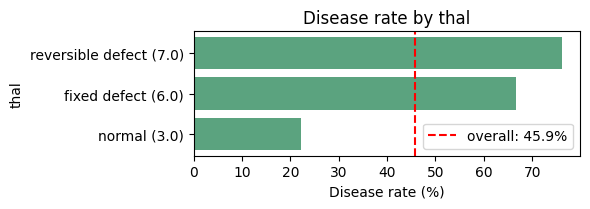

In [10]:
# For each categorical feature, plot disease rate per category as a horizontal bar.
# CATEGORY_LABELS maps numeric codes (e.g. cp=4) to human-readable terms ("asymptomatic")
# so the chart is readable in a defense setting. Red dashed line = overall cohort disease rate.

CATEGORY_LABELS = {
    "sex":     {0: "female", 1: "male"},
    "cp":      {1: "typical angina", 2: "atypical angina", 3: "non-anginal", 4: "asymptomatic"},
    "fbs":     {0: "fasting BG <=120", 1: "fasting BG >120"},
    "restecg": {0: "normal", 1: "ST-T abnormality", 2: "LV hypertrophy"},
    "exang":   {0: "no exercise angina", 1: "exercise angina"},
    "slope":   {1: "upsloping ST", 2: "flat ST", 3: "downsloping ST"},
    "ca":      {0: "0 vessels", 1: "1 vessel", 2: "2 vessels", 3: "3 vessels"},
    "thal":    {3: "normal", 6: "fixed defect", 7: "reversible defect"},
}

overall = df[TARGET_COL].mean()
for col in CATEGORICAL_FEATURES:
    rates = df.groupby(col)[TARGET_COL].mean().sort_values()
    labels = [f"{CATEGORY_LABELS.get(col, {}).get(k, k)} ({k})" for k in rates.index]
    fig, ax = plt.subplots(figsize=(6, 0.4 * max(3, len(rates)) + 1))
    ax.barh(labels, rates.values * 100, color="#5BA37F")
    ax.axvline(overall * 100, color="red", linestyle="--", label=f"overall: {overall*100:.1f}%")
    ax.set_xlabel("Disease rate (%)")
    ax.set_ylabel(col)
    ax.set_title(f"Disease rate by {col}")
    ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()

<!-- chart-narration -->
**Reading the categorical disease-rate panels.** Each bar shows the disease rate for one feature value; the red dashed line is the overall cohort rate (45.9%). Bars to the right of the line are higher-risk buckets.

Highlights consistent with cardiology literature:
- `sex`: males ~55% vs females ~25% - strong demographic effect, partly because this cohort over-samples symptomatic men referred for catheterisation.
- `cp` (chest pain type): asymptomatic patients (`cp=4`) have the highest disease rate (~73%) - a well-known clinical paradox. These patients were referred *despite* no chest pain, so something else (e.g. abnormal stress test) triggered the workup.
- `ca` (vessel count): monotone risk increase with number of diseased vessels - mechanistically expected.
- `thal` (perfusion defect): `reversible defect` (=7) is the highest-risk bucket, again clinically expected.
- `exang`: exercise-induced angina shifts disease rate up sharply.

What is good vs bad: features showing a *strong, monotone, mechanistically plausible* gradient (`ca`, `thal`, `exang`, `cp`) are good predictors. Features near the overall line (e.g. `fbs`) carry little signal.

## 6. Chi-square test of independence (categorical features vs target)
Lineage: P2 used Pearson's chi-square + Cramer's V to test association between a categorical predictor and a binary outcome. We apply the same test family per categorical clinical feature, with Bonferroni-style awareness that we are running several tests.

- $H_0$: outcome is independent of the feature.
- $H_1$: outcome is associated with the feature.
- $\alpha = 0.05$. Cramer's V is the practical-magnitude effect size (≈0.10 small / 0.30 medium / 0.50 large; Cohen, 1988).

In [11]:
# Cramer's V is the effect-size companion to a chi-square test. We report
# chi-square statistic, p-value, degrees of freedom, minimum expected count
# (must be >=5 for chi-square assumptions to hold), and Cramer's V per feature.
# Because we run one test per categorical feature on the same dataset, we also
# report a Bonferroni-corrected p-value (raw_p * number_of_tests, capped at 1.0)
# to guard against multiple-comparisons inflation.

def cramers_v(table: np.ndarray) -> float:
    chi2, _, _, _ = stats.chi2_contingency(table)
    n = table.sum()
    r, k = table.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1)))) if min(r, k) > 1 else float('nan')

n_tests = len(CATEGORICAL_FEATURES)
rows = []
for col in CATEGORICAL_FEATURES:
    sub = df[[col, TARGET_COL]].dropna()
    table = pd.crosstab(sub[col], sub[TARGET_COL]).values
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    chi2, p, dof, expected = stats.chi2_contingency(table)
    rows.append({
        'feature': col,
        'chi2': round(chi2, 3),
        'dof': dof,
        'p_value': p,
        'bonferroni_p': min(p * n_tests, 1.0),
        'min_expected': round(expected.min(), 2),
        'cramers_v': round(cramers_v(table), 3),
    })
chi_df = pd.DataFrame(rows).sort_values('cramers_v', ascending=False).reset_index(drop=True)
chi_df


,feature,chi2,dof,p_value,bonferroni_p,min_expected,cramers_v
0,thal,83.290,2,8.201820e-19,6.561456e-18,8.25,0.526
1,cp,81.816,3,1.251711e-17,1.001368e-16,10.55,0.520
2,ca,71.843,3,1.719952e-15,1.375961e-14,9.23,0.490
3,exang,54.686,1,1.413788e-13,1.131030e-12,45.42,0.425
4,slope,45.785,2,1.142885e-10,9.143076e-10,9.63,0.389
5,sex,22.043,1,2.666712e-06,2.133370e-05,44.50,0.270
6,restecg,10.052,2,6.566524e-03,5.253219e-02,1.83,0.182
7,fbs,0.077,1,7.812734e-01,1.000000e+00,20.64,0.016


**Reading the table.** Features with `bonferroni_p < 0.05` and `min_expected >= 5` show statistically reliable association with disease outcome after correcting for the multiple categorical tests run on the same dataset. Cramer's V indicates *how strong* the association is in practice. Expect `cp` (chest pain type), `thal`, `exang` (exercise-induced angina), and `ca` (number of vessels) to top this table — these are clinically well-established correlates of cardiovascular disease.


## 7. Correlation heatmap (numeric block)
Lineage: P2 used a correlation heatmap to flag collinearity in the macro-economic block. Same diagnostic here for numeric clinical features.

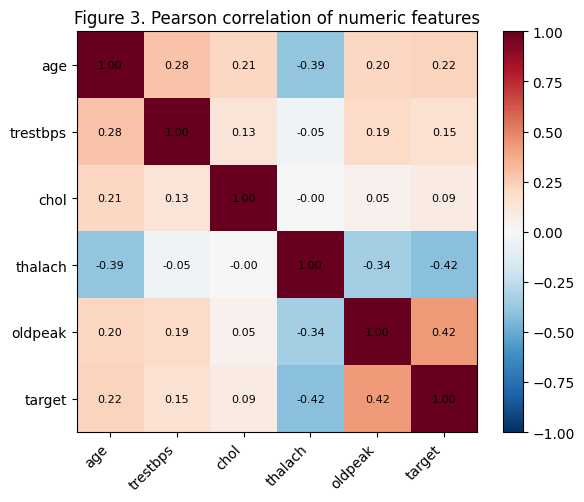

In [12]:
# Figure 3: Pearson correlation heatmap for numeric features and the target.
# Diagonal is 1.0 by construction; off-diagonal cells reveal collinearity and
# the strongest linear correlates of the target.

corr = df[NUMERIC_FEATURES + [TARGET_COL]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title('Figure 3. Pearson correlation of numeric features')
plt.tight_layout(); plt.show()

<!-- chart-narration -->
**Reading Figure 3.** Numeric-block correlations:
- All off-diagonal |r| values are < 0.5, so there is no severe collinearity. No feature needs to be dropped on collinearity grounds.
- Strongest *target* correlate among numerics is `thalach` (negative, ~-0.4) - fitter patients (higher max heart rate) have lower disease rate.
- Strongest *pairwise* correlation is age <-> thalach (negative, ~-0.4) - max heart rate declines with age, a well-known physiological fact.
- `oldpeak` is the second-strongest target correlate (positive). Combined with the categorical analysis, this reinforces that *exercise-test* features (`oldpeak`, `exang`, `slope`) are the highest-signal block.

Caveat: Pearson only captures linear monotone relationships. The chi-square / Cramer's V analysis above is the right tool for the categorical block.

## 8. Limitations and Potential Bias
Lineage: P2 included an explicit Limitations & Bias section *before* presenting model results. The same discipline applies here, made concrete to the healthcare setting.

**Limitation — small, single-source cohort.** UCI Heart Disease aggregates ~300 records from a small set of clinical sites (Cleveland, Hungarian, Switzerland, VA Long Beach). Findings on this cohort will not generalise to populations with different demographic mixes, comorbidity profiles, or measurement standards. Any model trained here is for prototyping the pipeline, not for clinical inference.

**Bias — selection and recording.** Records reflect patients who *presented* at the contributing centres and consented to invasive testing (cardiac catheterisation underlies several features). Patients who never reached a cardiology service are absent. Disease rates measured here are therefore conditional on referral and will be biased upward relative to the general population.

**Bias — demographic skew.** The cohort skews male and older. Any per-slice evaluation in later phases must explicitly disaggregate by `sex` and age band, mirroring the per-class disaggregated evaluation discipline adopted from Project 4 (Fashion-MNIST CNN with dropout) — where 'same headline accuracy, different per-class behaviour' was the key insight.

**Caveat — feature provenance.** Several predictors (e.g. `ca`, `thal`, `oldpeak`) come from invasive or stress tests. A real triage system cannot assume these are available at intake; the eventual deployment story would split features into 'cheap at intake' vs 'available after workup'. We flag this here but do not enforce it in the prototype.

## References
- Agresti, A. (2007). *An Introduction to Categorical Data Analysis* (2nd ed.). Wiley.
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum.
- Lusa, L. et al. (2024). Initial data analysis for longitudinal studies. *PLOS ONE*, 19(5).
- UCI Machine Learning Repository — Heart Disease Data Set (ID 45).